In [65]:
# Google Drive mount

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
import os

def set_default_directory(directory):
    """
    기본 작업 디렉토리를 설정하는 함수
    """
    os.chdir(directory)
    print("현재 작업 디렉토리를 설정했습니다:", os.getcwd())

In [67]:
# ipynb 파일이 있는 위치로 경로 설정
drive_path = '/content/drive/MyDrive/chapter6'
set_default_directory(drive_path)

현재 작업 디렉토리를 설정했습니다: /content/drive/MyDrive/chapter6


#  Chapter 6 Image Segmentation


# Exercise 1: Graylevel thresholding


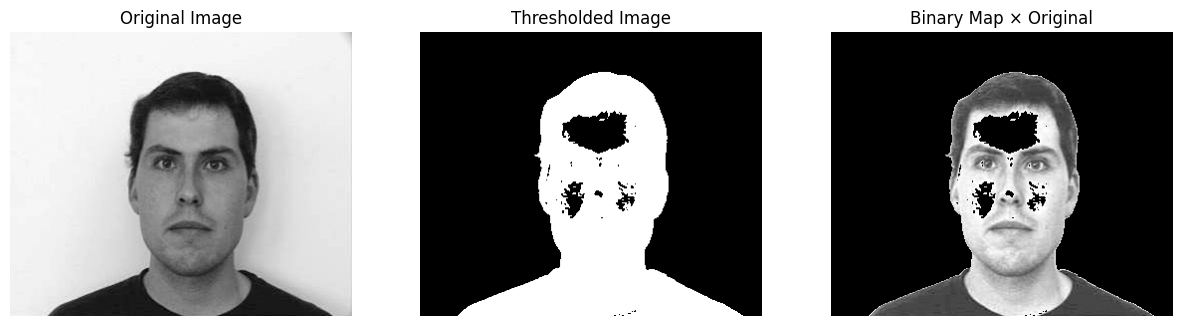

In [68]:
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np

# Load test image
img = Image.open('peter.png').convert('L')  # Convert to grayscale for simplicity
img_array = np.array(img)

# Threshold
level = 105
bwImg = img_array < level  # Create binary image based on threshold
holeImg = img_array * bwImg.astype(np.uint8)  # Create "hole" image

# Display images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_array, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(bwImg, cmap='gray')
axes[1].set_title('Thresholded Image')
axes[1].axis('off')

axes[2].imshow(holeImg, cmap='gray')
axes[2].set_title('Binary Map × Original')
axes[2].axis('off')

plt.show()

# Save images
bwImg_save = Image.fromarray((bwImg * 255).astype(np.uint8))
bwImg_save.save('Graylevel_Thresholding_thresholded.png')

holeImg_save = Image.fromarray(holeImg)
holeImg_save.save('Graylevel_Thresholding_blend.png')


# Exercise 2: Global Thresholding

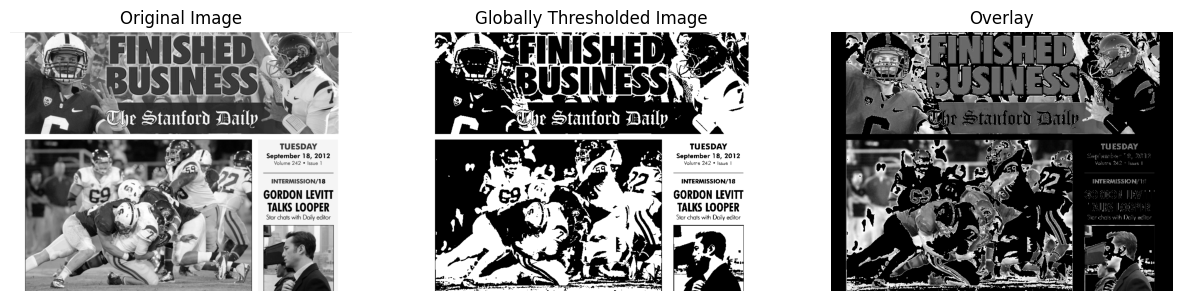

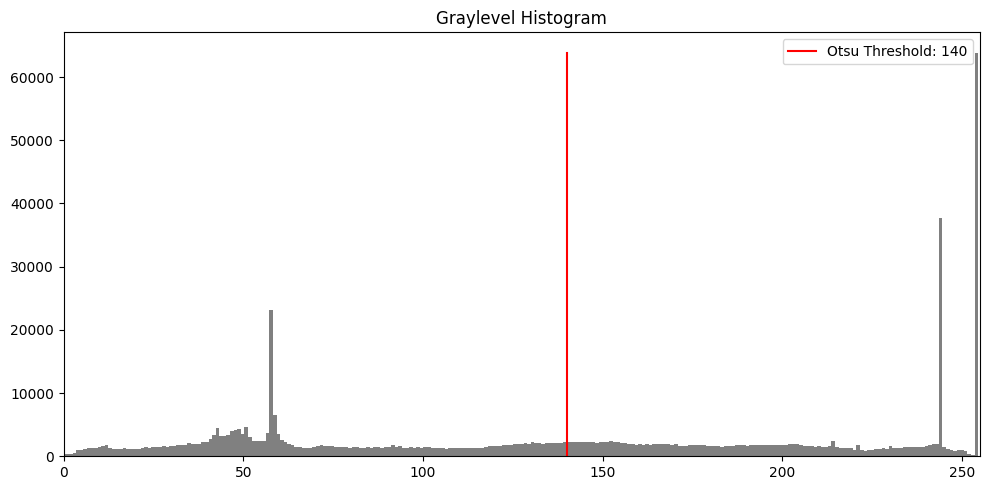

In [69]:
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np
from skimage import filters, io, color

# Load test image and convert it to grayscale
img = io.imread('front.png')  # Adjust the filename as needed
if img.ndim == 3:  # Check if the image is not already in grayscale
    img = color.rgb2gray(img) * 255
img = img.astype(np.uint8)  # Convert to uint8 for consistency with MATLAB

# Perform Otsu thresholding
level = filters.threshold_otsu(img)
otsuThresh = round(level)
bwImg = img > level  # Apply threshold

# Display images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(bwImg, cmap='gray')
axes[1].set_title('Globally Thresholded Image')
axes[1].axis('off')

overlay = np.where(bwImg, np.min(img), img)  # Using np.min(img) for the mask background
axes[2].imshow(overlay, cmap='gray')
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.show()

# Display histogram
fig, ax = plt.subplots(figsize=(10, 5))
counts, x = np.histogram(img, bins=256, range=(0, 255))
ax.bar(x[:-1], counts, width=1, color='gray')  # width set to 1 for proper bar display
ax.plot([otsuThresh, otsuThresh], [0, max(counts)], 'r-', label=f'Otsu Threshold: {otsuThresh}')
ax.set_xlim([0, 255])
ax.set_title('Graylevel Histogram')
ax.legend()
plt.tight_layout()

# Save images
bw_image_save = Image.fromarray((bwImg * 255).astype(np.uint8))
bw_image_save.save('Global_Thresholding_bw.png')
fig.savefig('Global_Thresholding_hist.png')


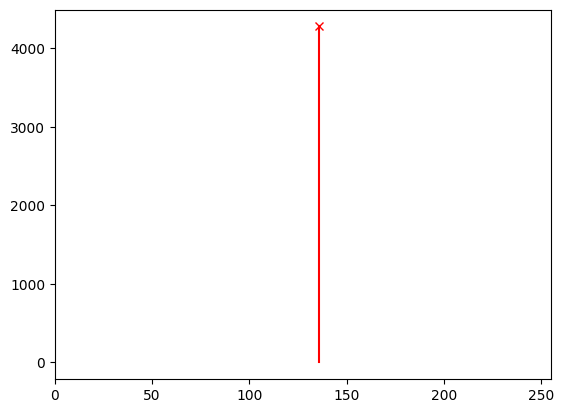

In [70]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from skimage import io, color, exposure

# Load image and convert to grayscale if necessary
I = io.imread('cman.png')
if I.ndim == 3:
    I = color.rgb2gray(I)
I = (I * 255).astype(np.uint8)

# Get histogram and total number of pixels
hist, bins = np.histogram(I.flatten(), 256, [0, 256])
N = hist.sum()

# Prepare video writer
fourcc = cv2.VideoWriter_fourcc(*'XVID')
v = cv2.VideoWriter('otsu_animation.avi', fourcc, 10.0, (640, 480))

sigmasq_b_max = 0
sigmasq_b_max_T = 0
sigmasq_b_all = np.zeros(256)

for T in range(1, 257):
    w_bg = np.sum(hist[:T]) / N
    w_fg = np.sum(hist[T:]) / N

    if w_bg == 0 or w_fg == 0:
        continue

    mu_bg = np.sum(np.dot(hist[:T], np.arange(T))) / np.sum(hist[:T])
    mu_fg = np.sum(np.dot(hist[T:], np.arange(T, 256))) / np.sum(hist[T:])

    sigmasq_b = w_bg * w_fg * (mu_bg - mu_fg) ** 2
    sigmasq_b_all[T-1] = sigmasq_b

    if sigmasq_b > sigmasq_b_max:
        sigmasq_b_max = sigmasq_b
        sigmasq_b_max_T = T-1

    # Visualization
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 2, 1)
    plt.imshow(I, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(I > T, cmap='gray')
    plt.title(f'Thresholded Image with T={T}')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.bar(bins[:-1], hist, width=0.8, color='gray')
    plt.plot([T, T], [0, max(hist)], 'r-')
    plt.xlim([0, 255])
    plt.title('Histogram of Original Image')

    plt.subplot(2, 2, 4)
    plt.plot(sigmasq_b_all, color='blue')
    plt.xlim([0, 255])
    plt.title('Between-class Variance')

    # Convert Matplotlib plot to OpenCV image
    plt.tight_layout()
    plt.draw()
    img_array = np.frombuffer(plt.gcf().canvas.tostring_rgb(), dtype=np.uint8)
    img_array = img_array.reshape(plt.gcf().canvas.get_width_height()[::-1] + (3,))
    img_array = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)
    v.write(img_array)

    plt.close()

# Mark the optimal threshold in the last frame
plt.plot(sigmasq_b_max_T, sigmasq_b_all[sigmasq_b_max_T], 'rx')
plt.plot([sigmasq_b_max_T, sigmasq_b_max_T], [0, sigmasq_b_all[sigmasq_b_max_T]], 'r-')
plt.xlim([0, 255])

v.release()


# Exercise 3 : Locally Adaptive Thresholding

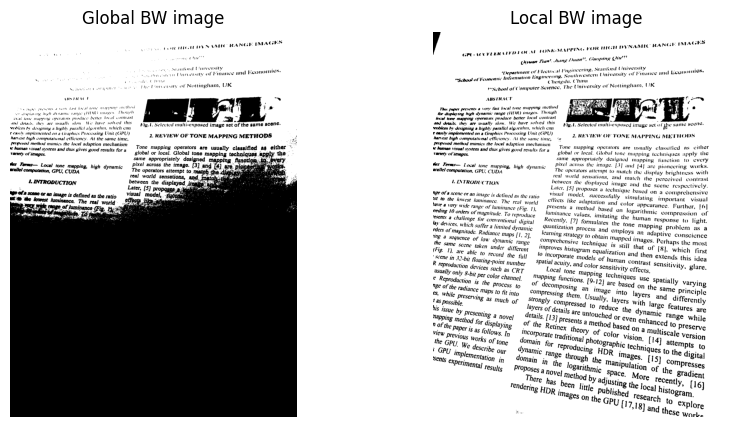

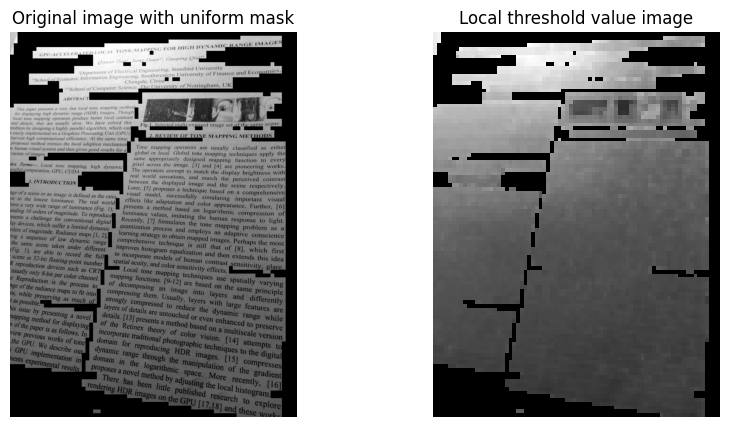

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, color, util
from skimage.measure import block_reduce

# Load test image and ensure it is in grayscale
img = io.imread('paper.png')
if img.ndim == 3:
    img = color.rgb2gray(img)
img = util.img_as_float(img)  # Convert image to floating point

# Perform global thresholding with Otsu's method
global_thresh = filters.threshold_otsu(img)
global_bw_img = img > global_thresh

# Decide local thresholding parameters
rows, cols = img.shape
step_size = 16
tile_size = 32
var_thresh = 0.0005

# Perform locally adaptive thresholding
local_bw_img = np.zeros((rows, cols))
uniform_mask = np.zeros((rows, cols))
thresh_im = np.zeros((rows // step_size, cols // step_size))

for i in range(0, rows, step_size):
    for j in range(0, cols, step_size):
        row_slice = slice(i, min(i + tile_size, rows))
        col_slice = slice(j, min(j + tile_size, cols))

        tile = img[row_slice, col_slice]

        # Calculate local variance
        var_step = np.var(tile)

        # Calculate local Otsu's threshold
        if var_step > var_thresh:
            local_thresh = filters.threshold_otsu(tile)
            local_bw_img[row_slice, col_slice] = tile > local_thresh
            uniform_mask[row_slice, col_slice] = 1
            thresh_im[i // step_size, j // step_size] = local_thresh
        else:
            local_mean = np.mean(tile)
            row_thresh = filters.threshold_otsu(img[max(0, i - step_size):i + step_size, :])
            if local_mean > min(row_thresh, global_thresh):
                local_bw_img[row_slice, col_slice] = 1
            else:
                local_bw_img[row_slice, col_slice] = 0
            thresh_im[i // step_size, j // step_size] = 0
            uniform_mask[row_slice, col_slice] = 0

# Show images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(global_bw_img, cmap='gray')
plt.title('Global BW image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(local_bw_img, cmap='gray')
plt.title('Local BW image')
plt.axis('off')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(uniform_mask * img, cmap='gray')
plt.title('Original image with uniform mask')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(thresh_im, cmap='gray')
plt.title('Local threshold value image')
plt.axis('off')

plt.show()

# Save images
io.imsave('Locally_Adaptive_Thresholding_global.png', util.img_as_ubyte(global_bw_img))
io.imsave('Locally_Adaptive_Thresholding_local.png', util.img_as_ubyte(local_bw_img))
io.imsave('Locally_Adaptive_Thresholding_uniformMask.png', util.img_as_ubyte(uniform_mask * img))
expanded_thresh_im = np.kron(thresh_im, np.ones((step_size, step_size)))
io.imsave('Locally_Adaptive_Thresholding_thresh.png', util.img_as_ubyte(expanded_thresh_im))


# Exercise 4: MAP Skin Detector

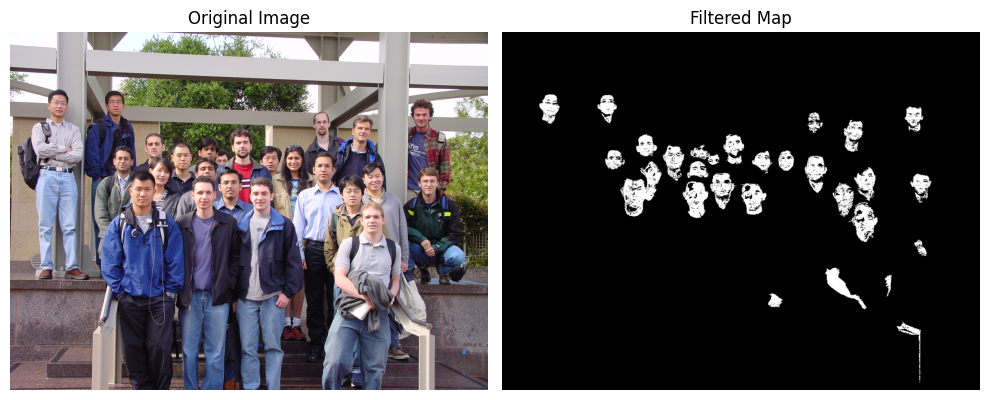

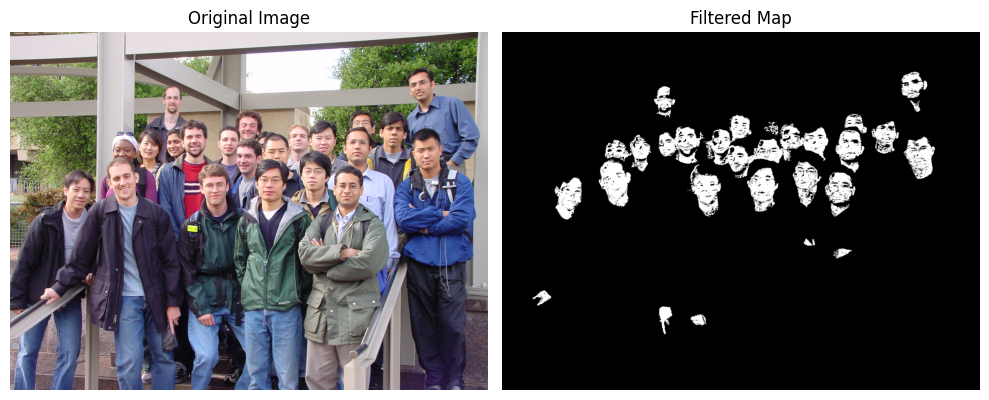

In [72]:
import numpy as np
from skimage import io, color
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
from scipy.ndimage import measurements

# Load training and testing images
numTraining = 5
imgTrain = [io.imread(f'Face_Training_{i}.jpg') for i in range(1, numTraining + 1)]
imgTrainMask = [io.imread(f'Face_ref_{i}.png') for i in range(1, numTraining + 1)]

numTesting = 2
imgTest = [io.imread(f'Face_Test_{i}.jpg') for i in range(1, numTesting + 1)]
step = 16
centroids1D = np.arange(step // 2, 256 + step // 2, step)
numCentroids1D = len(centroids1D)

# Initialize histograms
histSkin = np.zeros((numCentroids1D, numCentroids1D, numCentroids1D))
histNonSkin = np.zeros_like(histSkin)

for img, mask in zip(imgTrain, imgTrainMask):
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            pix = img[y, x]
            idx = ((pix // step).clip(max=numCentroids1D-1)).astype(int)
            if mask[y, x] > 0:
                histSkin[idx[0], idx[1], idx[2]] += 1
            else:
                histNonSkin[idx[0], idx[1], idx[2]] += 1

# MAP Classifier: Decide based on higher count in histogram
centroidClass = histSkin > histNonSkin
def apply_map_classifier(img, classifier, centroids1D):
    step = centroids1D[1] - centroids1D[0]
    binary_map = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            pix = img[y, x]
            idx = ((pix // step).clip(max=len(centroids1D)-1)).astype(int)
            binary_map[y, x] = classifier[idx[0], idx[1], idx[2]]
    return binary_map

# Example of applying the classifier to a test image
binary_maps = [apply_map_classifier(img, centroidClass, centroids1D) for img in imgTest]
import numpy as np
import cv2

# def areaFilter(colorThresh, upperLimit, lowerLimit):
#     """
#     Filters regions in a binary image based on their area.

#     Args:
#         colorThresh (numpy.ndarray): The binary image to be filtered.
#         upperLimit (int): The maximum allowed area size.
#         lowerLimit (int): The minimum allowed area size.

#     Returns:
#         numpy.ndarray: The filtered binary image.
#     """
#     areaThresh = np.copy(colorThresh)
#     # Find connected components and stats
#     num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(areaThresh.astype(np.uint8), connectivity=8)
#     for label in range(1, num_labels): # Skip background label
#         area = stats[label, cv2.CC_STAT_AREA]
#         if area > upperLimit or area < lowerLimit:
#             # Zero out pixels
#             areaThresh[labels == label] = 0
#     return areaThresh
def areaFilter(binary_map, min_area, max_area):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_map.astype(np.uint8), connectivity=8)
    filtered_map = np.zeros_like(binary_map, dtype=np.uint8)
    for label in range(1, num_labels):  # Label 0은 배경
        area = stats[label, cv2.CC_STAT_AREA]
        if min_area <= area <= max_area:
            filtered_map[labels == label] = 255
    return filtered_map
filtered_maps = [area_filter(binary_map, 500, 100000) for binary_map in binary_maps]
for i, (original, filtered) in enumerate(zip(imgTest, filtered_maps), 1):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(filtered, cmap='gray')
    plt.title('Filtered Map')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Save filtered maps
    io.imsave(f'Filtered_Face_{i}.png', (filtered * 255).astype(np.uint8))


# Exercise 5 : Region Labeling

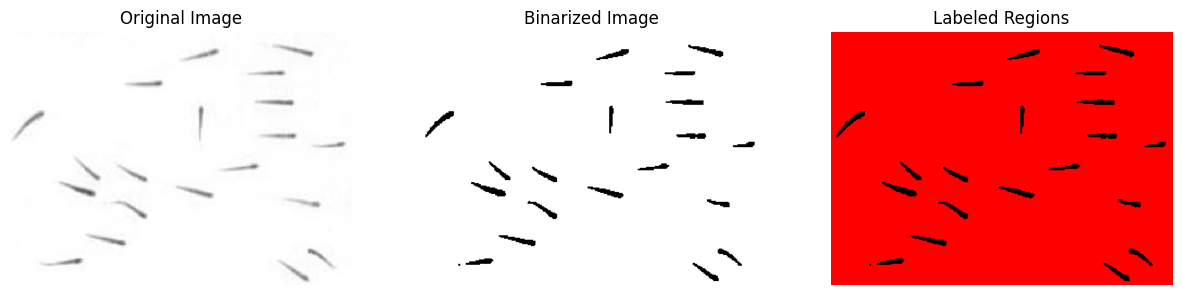

In [73]:
from skimage import io, color, filters, measure, segmentation
from skimage.morphology import closing, square
import matplotlib.pyplot as plt
import numpy as np

# Load test image
img = io.imread('fish.png')
if img.ndim == 3:  # Convert to grayscale if it's a color image
    img_gray = color.rgb2gray(img)
else:
    img_gray = img

# Binarize image using Otsu's threshold
thresh = filters.threshold_otsu(img_gray)
bwImg = closing(img_gray > thresh, square(3))

# Region labeling
label_image = measure.label(bwImg, connectivity=img_gray.ndim)
rgbLabel = color.label2rgb(label_image, bg_label=0)

# Show images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(bwImg, cmap='gray')
ax[1].set_title('Binarized Image')
ax[1].axis('off')

ax[2].imshow(rgbLabel)
ax[2].set_title('Labeled Regions')
ax[2].axis('off')

plt.show()

# Save images
io.imsave('Region_Labeling_bw.png', (bwImg * 255).astype(np.uint8))
rgbLabel_uint8 = (rgbLabel * 255).astype(np.uint8)
io.imsave('Region_Labeling_rgbLabel.png', rgbLabel_uint8)


# Exercise 6 :Hole Filling

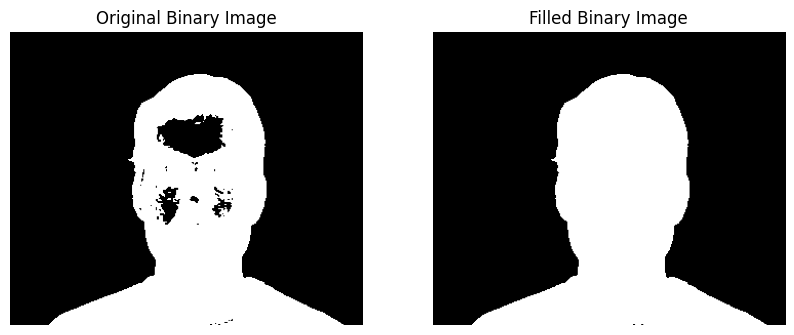

In [74]:
from PIL import Image
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

# Load test image and convert it to grayscale
img = Image.open('face.png').convert('L')
img_array = np.array(img)

# Binarize image
level = 105
bwImg = img_array < level

# Fill holes in the binary image
filledBwImg = ndimage.binary_fill_holes(bwImg).astype(int)

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(bwImg, cmap='gray')
plt.title('Original Binary Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filledBwImg, cmap='gray')
plt.title('Filled Binary Image')
plt.axis('off')

plt.show()

# Save images
Image.fromarray((bwImg * 255).astype(np.uint8)).save('Hole_Filling_bw.png')
Image.fromarray((filledBwImg * 255).astype(np.uint8)).save('Hole_Filling_filled.png')


#Exericse 7 : Bar_code_Detection

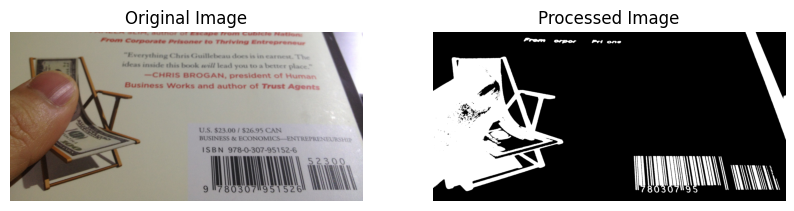

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, measure, morphology
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.transform import resize

def localAdaptiveOtsu(I, winSize, stepSize, var_thresh):
    # Convert to grayscale if it's not already
    if I.ndim == 3:
        I = color.rgb2gray(I)

    Nrow, Ncol = I.shape
    globalOtsuLevel = threshold_otsu(I)
    localThresh = np.full((Nrow // stepSize, Ncol // stepSize), globalOtsuLevel)
    localThreshUsed = np.zeros_like(localThresh, dtype=bool)
    BW = np.zeros((Nrow, Ncol), dtype=bool)

    for i in range(0, Nrow, stepSize):
        for j in range(0, Ncol, stepSize):
            patch = I[i:i+winSize, j:j+winSize]
            if np.var(patch) > var_thresh:
                localThresh[i // stepSize, j // stepSize] = threshold_otsu(patch)
                BW[i:i+stepSize, j:j+stepSize] = patch[:stepSize, :stepSize] > localThresh[i // stepSize, j // stepSize]
                localThreshUsed[i // stepSize, j // stepSize] = True
            else:
                BW[i:i+stepSize, j:j+stepSize] = patch[:stepSize, :stepSize] > globalOtsuLevel

    # Interpolating local thresholds for visualization
    localThreshInterp = resize(localThresh, I.shape, order=1, preserve_range=True)
    localThreshUsedInterp = resize(localThreshUsed.astype(float), I.shape, order=0, preserve_range=True)

    return BW, localThreshUsedInterp, localThreshInterp

def processImage(image_path):
    img = io.imread(image_path)
    img_cropped = img[:img.shape[0]//32*32, :img.shape[1]//32*32]
    img_gray = color.rgb2gray(img_cropped)

    winSize, stepSize, var_thresh = 32, 16, 60
    imgBW, _, _ = localAdaptiveOtsu(img_gray, winSize, stepSize, var_thresh)
    imgBW = np.logical_not(imgBW)  # Invert binary image

    # Label the image and filter based on properties
    label_img = label(imgBW)
    props = regionprops(label_img)

    # Filter based on eccentricity and major axis length
    for prop in props:
        if prop.eccentricity < 0.5 or prop.major_axis_length < 100:  # Adjust these values as needed
            imgBW[label_img == prop.label] = False

    # Visualize the result
    plt.figure(figsize=(10, 5))
    plt.subplot(121)
    plt.imshow(img_cropped, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(imgBW, cmap='gray')
    plt.title('Processed Image')
    plt.axis('off')

    plt.show()


processImage('book.png')
